In [1]:
import os
import numpy as np
import scipy.io as spio
import struct
import matplotlib.pyplot as plt

In [2]:
N_SEG_IN   = 27904 # number of segments before cut
N_SEG_BIN = 10999 # number of ever active segments after cut

In [3]:
# read segnum with information of grid id
mat = spio.loadmat("<MODEL_DIR>/segment number.mat")
segnum = mat['data'][0,0]['Val']

In [4]:
segnum.shape # (M, N, K)

(60, 50, 16)

In [5]:
### Define mask to identify segnum coordinates matching ever active cells - step to transpose bin into grid ###

# ── Build ever-active mask from baseline original .vol ────────────────────────
SCEN_VOL_ORIG = r'<MODEL_DIR>\com_files\com-WQexport_30min_fullperiod.vol'  # ← baseline original FLOW vol
rec_size_s    = (N_SEG_IN + 1) * 4
fsize         = os.path.getsize(SCEN_VOL_ORIG)
n_times       = fsize // rec_size_s

ever_active = np.zeros(N_SEG_IN, dtype=bool)
print('Reading baseline original .vol to find ever-active segments...')
with open(SCEN_VOL_ORIG, 'rb') as f:
    for i in range(n_times):
        f.read(4)
        raw = np.frombuffer(f.read(N_SEG_IN * 4), dtype='<f4').copy()
        ever_active |= (raw > 0)
        if (i+1) % 2000 == 0:
            print(f'  {i+1:,}/{n_times:,}...', end='\r')

all_active_idx = np.where(ever_active)[0]
print(f'\nTotal ever-active: {len(all_active_idx)}')
new_to_old = all_active_idx[:N_SEG_BIN]
print(f'Using first {len(new_to_old)} active segments')

Reading baseline original .vol to find ever-active segments...
  14,000/15,032...
Total ever-active: 10999
Using first 10999 active segments


In [6]:
def array_bin_to_grid(x_bin, new_to_old, segnum):
    """Map WAQ segment values to (M, N, K) grid using segnum lookup."""
    # Step 1: place compact-grid values back into full FLOW-segment positions
    x_full = np.full(N_SEG_IN, np.nan, dtype=float)
    x_full[new_to_old] = x_bin

    # Step 2: fancy-index segnum into x_full
    # segnum contains 1-indexed segment IDs with NaN for inactive cells
    out = np.full(segnum.shape, np.nan, dtype=float)
    valid = ~np.isnan(segnum)
    seg_idx = segnum[valid].astype(np.int64) - 1   # 1-indexed → 0-indexed
    out[valid] = x_full[seg_idx]
    return out

In [7]:
# Reads binary file and converges values to (M, N, K) grid positions, saving times and arrays as lists
bin_path = "<MODEL_DIR>/01scen_baseline/com-WQexport_clean.tem"
fsize    = os.path.getsize(bin_path) # bin_path is path to binary file (WAQ output) that will be plotted 
rec_size = (N_SEG_BIN + 1) * 4
n_recs   = fsize // rec_size
times = []
arrays = []
with open(bin_path, 'rb') as f:
    for i in range(n_recs):
        ts_bytes = f.read(4)
        if len(ts_bytes) < 4: break
        ts = struct.unpack("i", ts_bytes)[0]
        x_bin = np.frombuffer(f.read(N_SEG_BIN * 4), dtype='<f4').copy()
        x_grid = array_bin_to_grid(x_bin, new_to_old, segnum)
        times.append(ts)
        arrays.append(x_grid)
        if (i+1) % 1000 == 0 or i == n_recs-1:
            print(f'  {i+1:,}/{n_recs:,}...', end='\r')

  15,032/15,032...

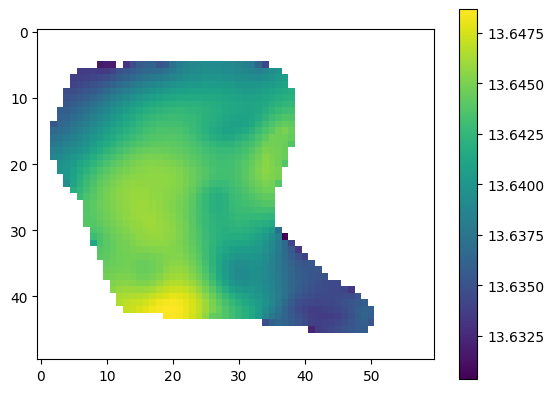

In [80]:
# Plot to check mapping
plt.imshow(np.rot90(arrays[190][:, :, 8]), origin= 'upper')
plt.colorbar()

In [ ]:
# Try to save as NETCDF file to use same codes as before